# **Harris Detection Corner**

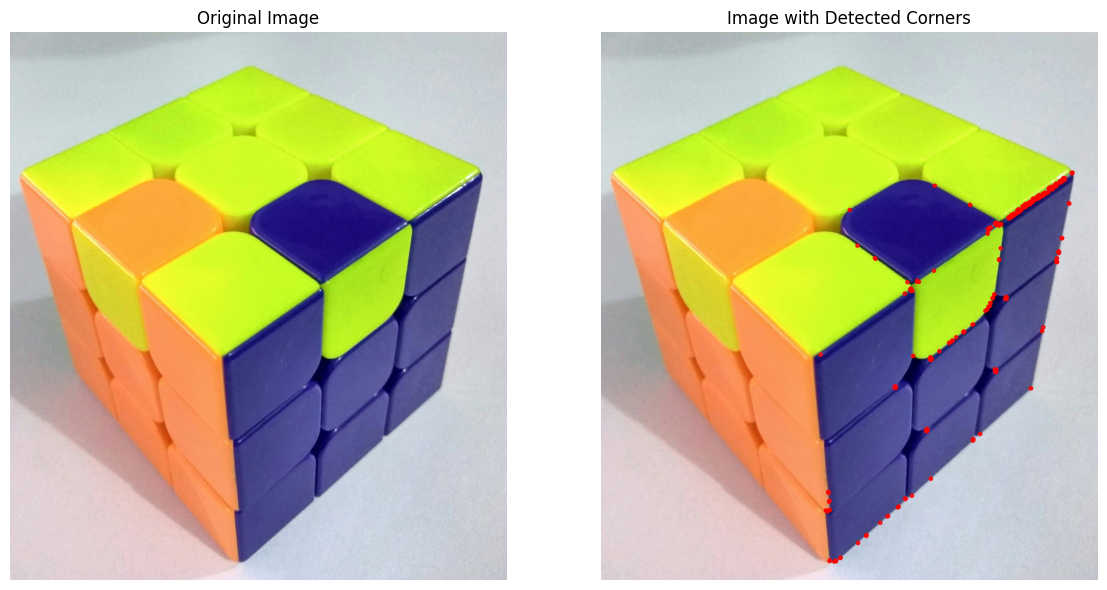

Number of detected corners: 2717


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread("cube.jpg")

# Converting the image into grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Harris Corner Detection
harris_corners = cv2.cornerHarris(gray_image, blockSize=2, ksize=3, k=0.04)

# Dilate the result to mark the corners
harris_corners = cv2.dilate(harris_corners, None)

# Threshold for an optimal value, it may vary depending on the image
threshold = 0.01 * harris_corners.max()

# Create a copy of the original image to draw corners on
image_with_corners = np.copy(image)

# Get the coordinates of detected corners
y, x = np.where(harris_corners > threshold)

# Iterate through all the corners and draw larger circles on the image
for i, j in zip(x, y):
    cv2.circle(image_with_corners, (i, j), radius=5, color=(0, 0, 255), thickness=2)

# Display the results
plt.figure(figsize=(12, 6))

plt.subplot(121)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(122)
plt.imshow(cv2.cvtColor(image_with_corners, cv2.COLOR_BGR2RGB))
plt.title('Image with Detected Corners')
plt.axis('off')

plt.tight_layout()
plt.show()

# Print the number of detected corners
print(f"Number of detected corners: {len(x)}")

# **HOG (Histogram of Oriented Gradients) Feature Extraction**

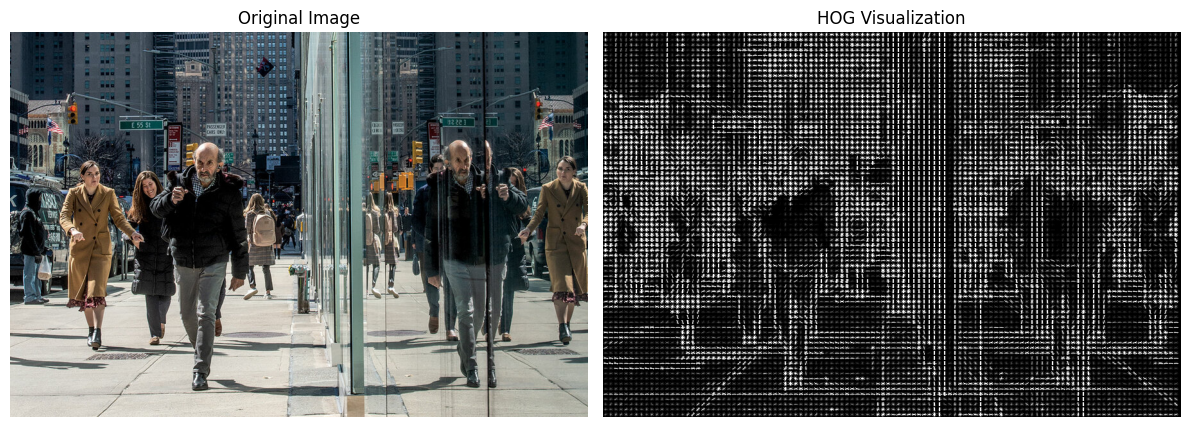

Shape of HOG features: (295704,)
Number of HOG features: 295704


In [2]:
import cv2
import numpy as np
from skimage.feature import hog
from skimage import exposure
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread("city.jpg")

# Converting the image into grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply the HOG descriptor
fd, hog_image = hog(gray_image, orientations=9, pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2), visualize=True)

# Rescale histogram for better display
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

# Visualize the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

ax1.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
ax1.set_title('Original Image')
ax1.axis('off')

ax2.imshow(hog_image_rescaled, cmap='gray')
ax2.set_title('HOG Visualization')
ax2.axis('off')

plt.tight_layout()
plt.show()

# Print some information about the HOG features
print(f"Shape of HOG features: {fd.shape}")
print(f"Number of HOG features: {fd.size}")

# **FAST (Features from Accelerated Segment Test) Keypoint Detection**

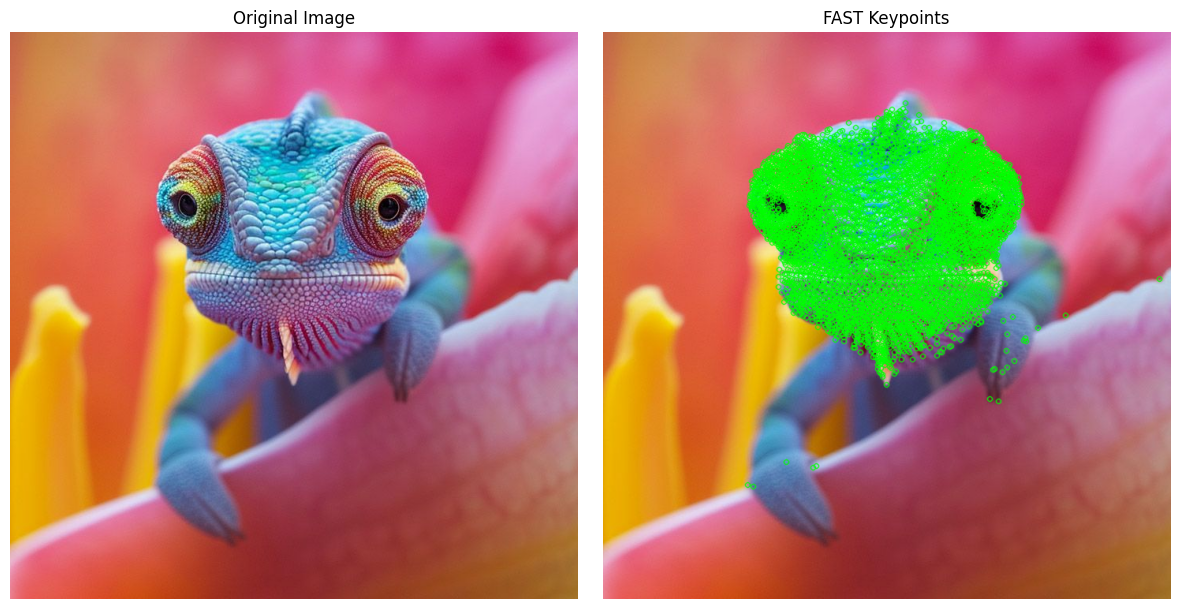

Number of keypoints detected: 5200
FAST parameters:
Threshold: 10
nonmaxSuppression: True
neighborhood: 2


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread("cam.jpg")

# Get image dimensions
height, width, _ = image.shape

# Determine the size of the square (based on the smallest side)
square_size = min(height, width)

# Compute cropping dimensions (center crop)
y_offset = (height - square_size) // 2
x_offset = (width - square_size) // 2

# Crop the image to a square
square_image = image[y_offset:y_offset + square_size, x_offset:x_offset + square_size]

# Converting the image to grayscale
gray_image = cv2.cvtColor(square_image, cv2.COLOR_BGR2GRAY)

# Create FAST object
fast = cv2.FastFeatureDetector_create()

# Detect keypoints
keypoints = fast.detect(gray_image, None)

# Draw keypoints on the cropped square image
image_with_keypoints = cv2.drawKeypoints(square_image, keypoints, None, color=(0, 255, 0))

# Visualize the results
plt.figure(figsize=(12, 6))

plt.subplot(121)
plt.imshow(cv2.cvtColor(square_image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(122)
plt.imshow(cv2.cvtColor(image_with_keypoints, cv2.COLOR_BGR2RGB))
plt.title('FAST Keypoints')
plt.axis('off')

plt.tight_layout()
plt.show()

# Print the number of keypoints detected
print(f"Number of keypoints detected: {len(keypoints)}")

# Print some FAST parameters
print("FAST parameters:")
print(f"Threshold: {fast.getThreshold()}")
print(f"nonmaxSuppression: {fast.getNonmaxSuppression()}")
print(f"neighborhood: {fast.getType()}")

# **Feature Matching using ORB and FLANN**

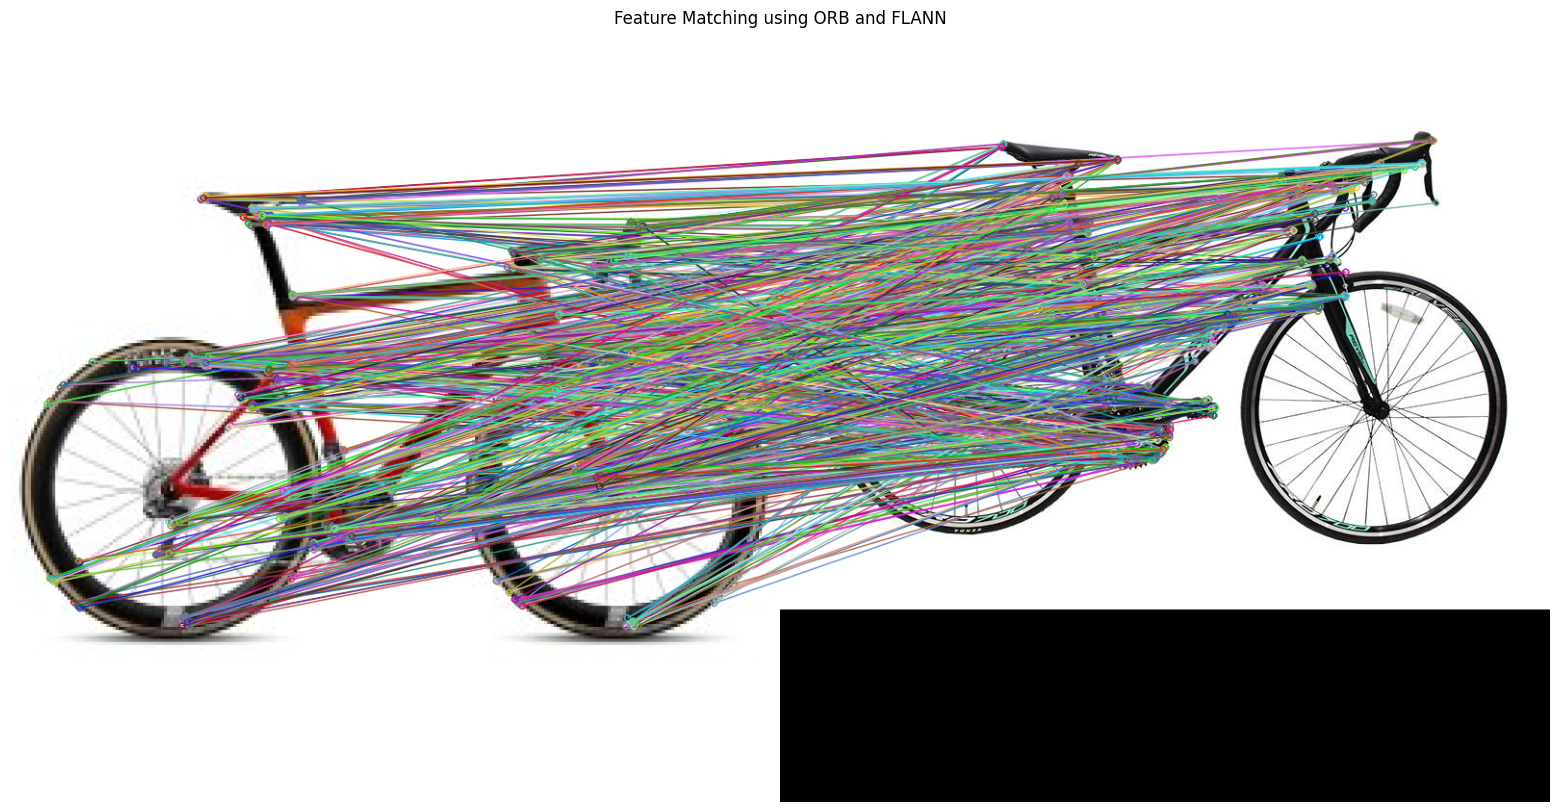

Number of keypoints in image 1: 500
Number of keypoints in image 2: 500
Number of matches: 1000


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def load_and_preprocess(image_path, target_size=800):
  # Load the image
  image = cv2.imread(image_path)

  # Get image dimensions
  height, width = image.shape[:2]

  # Calculate aspect ratio
  aspect_ratio = width / height

  # Determine new dimensions
  if width > height:
    new_width = target_size
    new_height = int(new_width / aspect_ratio)
  else:
    new_height = target_size
    new_width = int(new_height * aspect_ratio)

  # Resize the image
  resized_image = cv2.resize(image, (new_width, new_height), interpolation=cv2.INTER_AREA)

  # Converting the image to grayscale
  gray_image = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)

  return resized_image, gray_image

# Load and preprocess both images
image1, gray1 = load_and_preprocess("rb1.jpg")
image2, gray2 = load_and_preprocess("rb2.jpg")

# Initialize ORB detector
orb = cv2.ORB_create()

# Find the keypoints and descriptors with ORB
kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

# FLANN parameters
FLANN_INDEX_LSH = 6
index_params= dict(algorithm = FLANN_INDEX_LSH,
                   table_number = 6,
                   key_size = 12,
                   multi_probe_level = 1)
search_params = dict(checks=50)

# Initialize FLANN matcher
flann = cv2.FlannBasedMatcher(index_params, search_params)

# Perform matching
matches = flann.knnMatch(des1, des2, k=2)

# Flatten the matches list
all_matches = [item for sublist in matches for item in sublist]

# Draw all matches
img_matches = cv2.drawMatches(image1, kp1, image2, kp2, all_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Display results
plt.figure(figsize=(20, 10))
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title('Feature Matching using ORB and FLANN')
plt.axis('off')
plt.show()

# Print some information
print(f"Number of keypoints in image 1: {len(kp1)}")
print(f"Number of keypoints in image 2: {len(kp2)}")
print(f"Number of matches: {len(all_matches)}")

# **Image Segmentation using Watershed Algorithm**

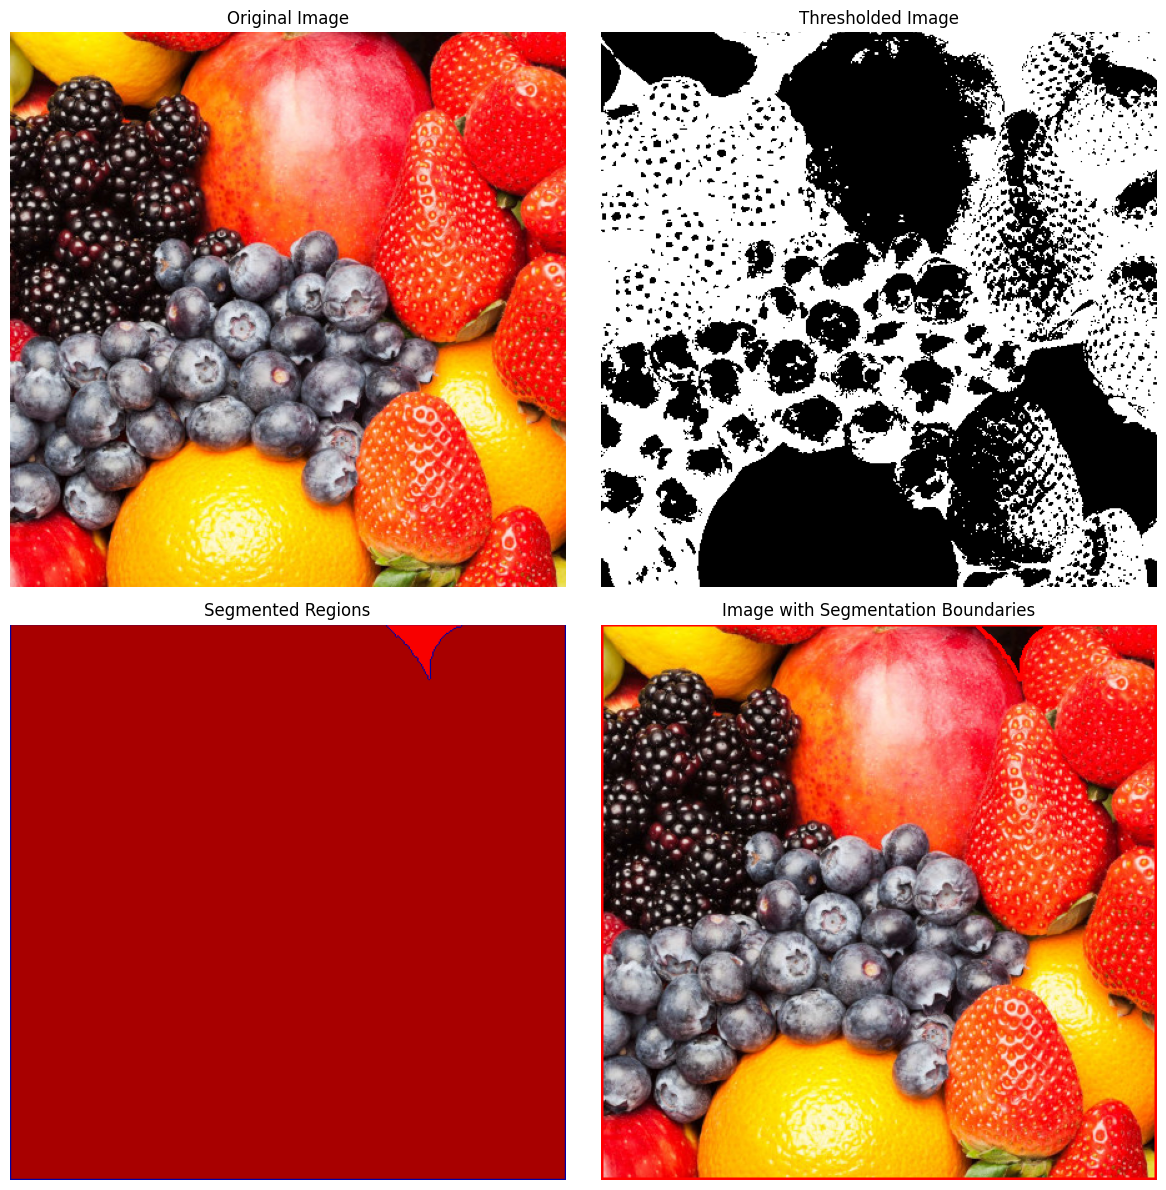

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def crop_square(img):
  h, w = img.shape[:2]
  min_dim = min(h, w)

  # Calculate cropping area
  top = (h - min_dim) // 2
  bottom = top + min_dim
  left = (w - min_dim) // 2
  right = left + min_dim

  # Crop the image to the square
  return img[top:bottom, left:right]

# Load and preprocess the image
image = cv2.imread("fruits.jpg")

# Crop the image to make it square
image = crop_square(image)

# Convert to RGB (matplotlib uses RGB)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert the image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply threshold to get binary image
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Noise removal using morphological opening
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Sure background area
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Finding sure foreground area
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist_transform, 0.7*dist_transform.max(), 255, 0)

# Finding unknown region
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

# Marker labelling
ret, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

# Apply watershed algorithm
markers = cv2.watershed(image, markers)

# Create a copy of the image to draw contours
image_with_contours = image_rgb.copy()

# Draw thicker contours on the image
boundary_mask = np.uint8(markers == -1)  # Convert boolean mask to uint8
dilated_boundary = cv2.dilate(boundary_mask, kernel)  # Apply dilation
image_with_contours[dilated_boundary == 1] = [255, 0, 0]

# Crop all images to square
image_rgb_square = crop_square(image_rgb)
thresh_square = crop_square(thresh)
markers_square = crop_square(cv2.applyColorMap((markers * 10).astype(np.uint8), cv2.COLORMAP_JET))
image_with_contours_square = crop_square(image_with_contours)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
ax = axes.ravel()

ax[0].imshow(image_rgb_square)
ax[0].set_title("Original Image")
ax[0].axis('off')

ax[1].imshow(thresh_square, cmap='gray')
ax[1].set_title("Thresholded Image")
ax[1].axis('off')

ax[2].imshow(markers_square, cmap='jet')
ax[2].set_title("Segmented Regions")
ax[2].axis('off')

ax[3].imshow(image_with_contours_square)
ax[3].set_title("Image with Segmentation Boundaries")
ax[3].axis('off')

plt.tight_layout()
plt.show()